In [1]:
# 本项目来源于和鲸社区，使用转载需要标注来源
# 作者: 代维
# 来源: https://www.heywhale.com/mw/project/69987eec9bb7c0d2d559ed2e

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import gaussian_kde
import os
# 设置中文显示，避免图表乱码
plt.rcParams['font.sans-serif'] = ['SimHei']  #  Windows用这个
plt.rcParams['axes.unicode_minus'] = False
figure_dir = 'D:/26实习/value_segmentation-main/figure'
os.makedirs(figure_dir, exist_ok=True)

In [2]:
#读取数据
df = pd.read_excel('D:/26实习/value_segmentation-main/data/user_personalized_features.xlsx', engine='openpyxl')

In [3]:
print("数据基本信息：")
print(df.info())
print("\n数据描述性统计：")
print(df.describe())

数据基本信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   User_ID                      1000 non-null   object
 1   Age                          1000 non-null   int64 
 2   Gender                       1000 non-null   object
 3   Location                     1000 non-null   object
 4   Income                       1000 non-null   int64 
 5   Interests                    1000 non-null   object
 6   Last_Login_Days_Ago          1000 non-null   int64 
 7   Purchase_Frequency           1000 non-null   int64 
 8   Average_Order_Value          1000 non-null   int64 
 9   Total_Spending               1000 non-null   int64 
 10  Product_Category_Preference  1000 non-null   object
 11  Time_Spent_on_Site_Minutes   1000 non-null   int64 
 12  Pages_Viewed                 1000 non-null   int64 
 13  Newsletter_Subscription   

In [4]:
#数据预处理，处理重复值、缺失值
print("\n各字段缺失值数量：")
print(df.isnull().sum())

print("\n重复数据行数：", df.duplicated().sum())
df = df.drop_duplicates()

df = df[(df['Age'] >= 18) & (df['Age'] <= 70)]  # 只保留18-70岁的合理用户
df = df[df['Purchase_Frequency'] >= 0]  # 购买频率不能为负
df = df[df['Total_Spending'] >= 0]  # 消费额不能为负


各字段缺失值数量：
User_ID                        0
Age                            0
Gender                         0
Location                       0
Income                         0
Interests                      0
Last_Login_Days_Ago            0
Purchase_Frequency             0
Average_Order_Value            0
Total_Spending                 0
Product_Category_Preference    0
Time_Spent_on_Site_Minutes     0
Pages_Viewed                   0
Newsletter_Subscription        0
dtype: int64

重复数据行数： 0


In [5]:
df = df.reset_index(drop=True)
print(f"\n清洗后数据量：{df.shape[0]}行，{df.shape[1]}列")


清洗后数据量：1000行，14列


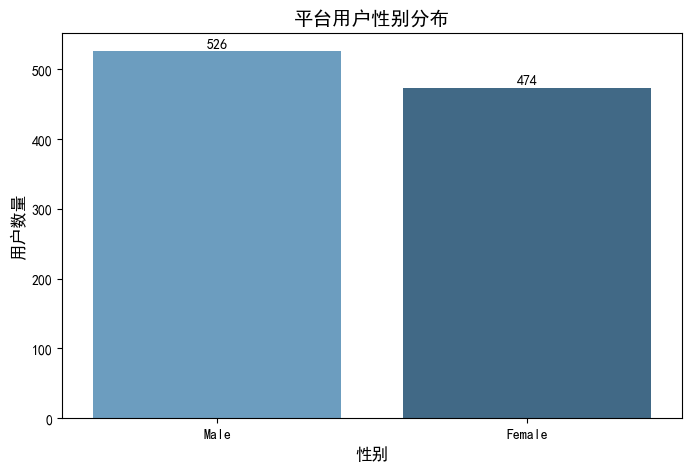

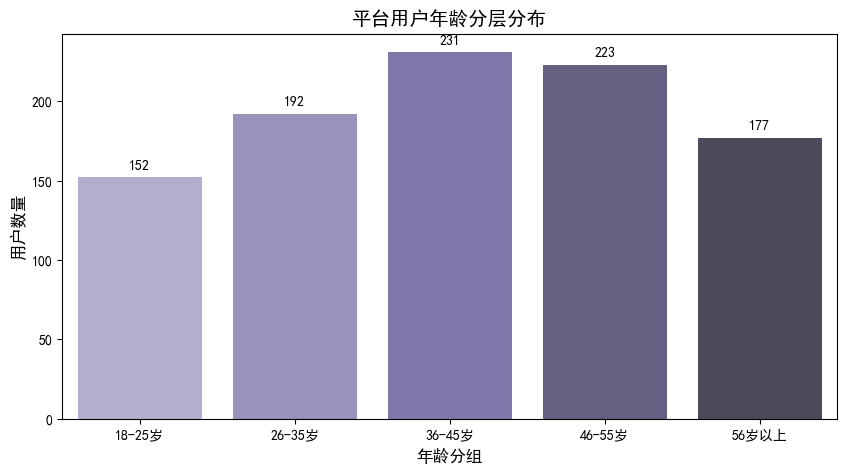

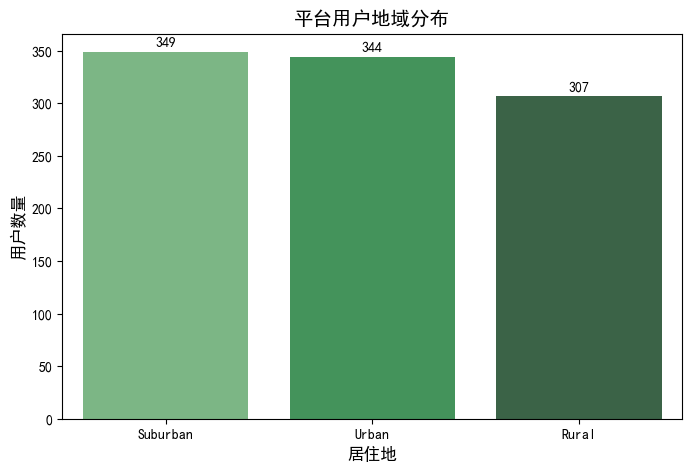

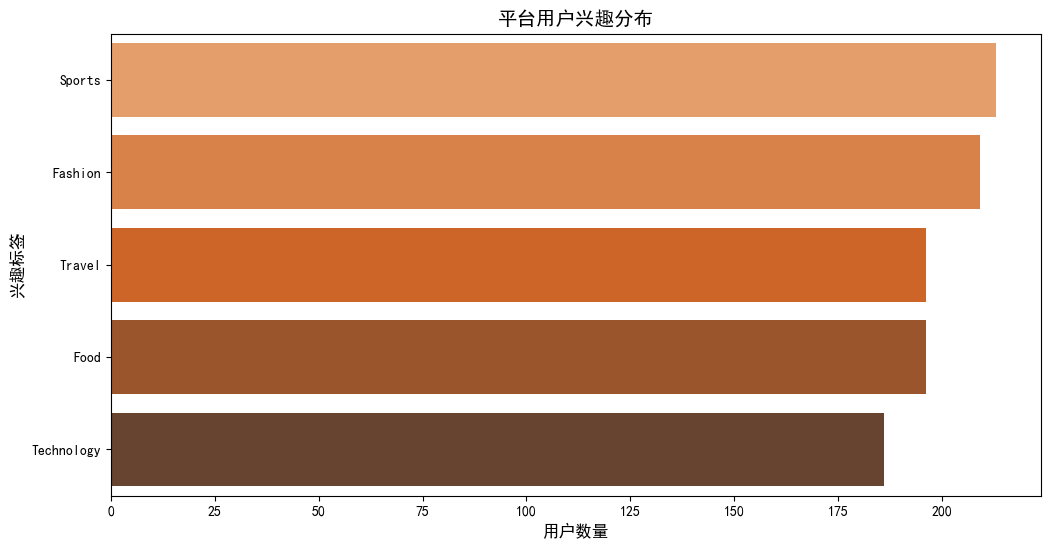

In [15]:
# 1. 性别分布
plt.figure(figsize=(8, 5))
gender_count = df['Gender'].value_counts().reset_index()
gender_count.columns = ['Gender', 'Count']

sns.barplot(
    data=gender_count,
    x='Gender',
    y='Count',
    hue='Gender',
    palette='Blues_d',
    legend=False
)

plt.title('平台用户性别分布', fontsize=14)
plt.xlabel('性别', fontsize=12)
plt.ylabel('用户数量', fontsize=12)

for i, v in enumerate(gender_count['Count']):
    plt.text(i, v + 5, str(v), ha='center', fontsize=10)

plt.savefig(os.path.join(figure_dir, '用户性别分布.png'), dpi=300, bbox_inches='tight')
plt.show()


# 2. 年龄分层分布
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[18, 25, 35, 45, 55, 70],
    labels=['18-25岁', '26-35岁', '36-45岁', '46-55岁', '56岁以上']
)

plt.figure(figsize=(10, 5))
age_count = df['Age_Group'].value_counts().sort_index().reset_index()
age_count.columns = ['Age_Group', 'Count']

sns.barplot(
    data=age_count,
    x='Age_Group',
    y='Count',
    hue='Age_Group',
    palette='Purples_d',
    legend=False
)

plt.title('平台用户年龄分层分布', fontsize=14)
plt.xlabel('年龄分组', fontsize=12)
plt.ylabel('用户数量', fontsize=12)

for i, v in enumerate(age_count['Count']):
    plt.text(i, v + 5, str(v), ha='center', fontsize=10)

plt.savefig(os.path.join(figure_dir, '用户年龄分布.png'), dpi=300, bbox_inches='tight')
plt.show()


# 3. 用户地域分布
plt.figure(figsize=(8, 5))
location_count = df['Location'].value_counts().reset_index()
location_count.columns = ['Location', 'Count']

sns.barplot(
    data=location_count,
    x='Location',
    y='Count',
    hue='Location',
    palette='Greens_d',
    legend=False
)

plt.title('平台用户地域分布', fontsize=14)
plt.xlabel('居住地', fontsize=12)
plt.ylabel('用户数量', fontsize=12)

for i, v in enumerate(location_count['Count']):
    plt.text(i, v + 5, str(v), ha='center', fontsize=10)

plt.savefig(os.path.join(figure_dir, '用户地域分布.png'), dpi=300, bbox_inches='tight')
plt.show()


# 4. 用户兴趣分布
plt.figure(figsize=(12, 6))
interest_count = df['Interests'].value_counts().reset_index()
interest_count.columns = ['Interests', 'Count']

sns.barplot(
    data=interest_count,
    x='Count',
    y='Interests',
    hue='Interests',
    palette='Oranges_d',
    legend=False
)

plt.title('平台用户兴趣分布', fontsize=14)
plt.xlabel('用户数量', fontsize=12)
plt.ylabel('兴趣标签', fontsize=12)

plt.savefig(os.path.join(figure_dir, '用户兴趣分布.png'), dpi=300, bbox_inches='tight')
plt.show()

3.1 平台用户全景画像分析
3.1.1 用户人口属性分布
性别分布：平台男性用户 526 人，占比 52.7%；女性用户 474 人，占比 47.3%，男女用户结构均衡，无明显性别倾斜。运营策略需兼顾两性需求，同时可针对占比略高的男性用户，适度倾斜对应品类的运营资源。

年龄分层分布：平台核心用户集中在 36-55 岁，其中 36-45 岁用户 231 人、46-55 岁用户 223 人，合计占比超 45%，是平台的营收主力群体；18-25 岁年轻用户仅 152 人，占比最低，是平台用户增长的核心潜力缺口。

年龄与消费能力关联：各年龄层用户平均总消费均稳定在 2500-2600 元，其中 56 岁以上用户平均消费最高（2603 元），46-55 岁次之（2596 元），说明平台用户消费能力无明显年龄壁垒，中老年用户具备极强的消费潜力。

3.1.2 用户地域与偏好分布
地域分布：郊区用户 349 人，占比最高；城市用户 344 人，农村用户 307 人。下沉市场（郊区 + 农村）用户合计占比超 65%，是平台的用户基本盘，运营需重点匹配下沉市场用户的消费习惯。

兴趣与品类偏好：

用户兴趣 TOP3：Sports、Fashion、Travel；

核心关联洞察：用户兴趣与品类偏好高度匹配，运动、时尚兴趣直接对应服饰品类的核心消费，为场景化推荐、品类联动运营提供了数据支撑。

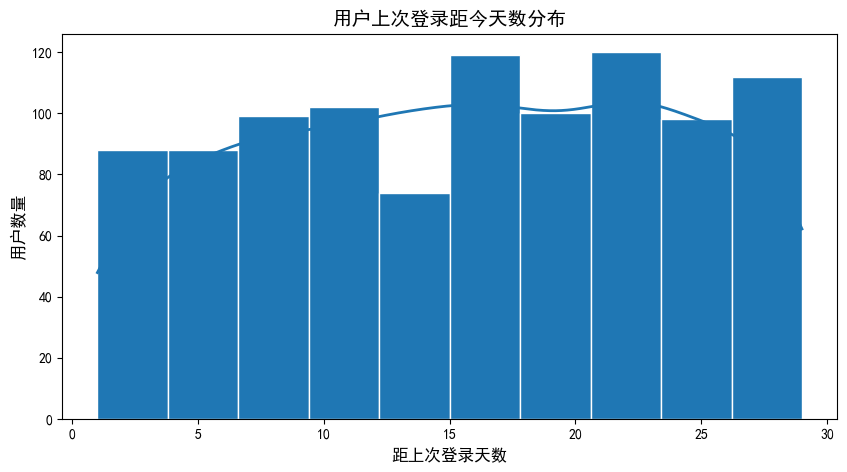

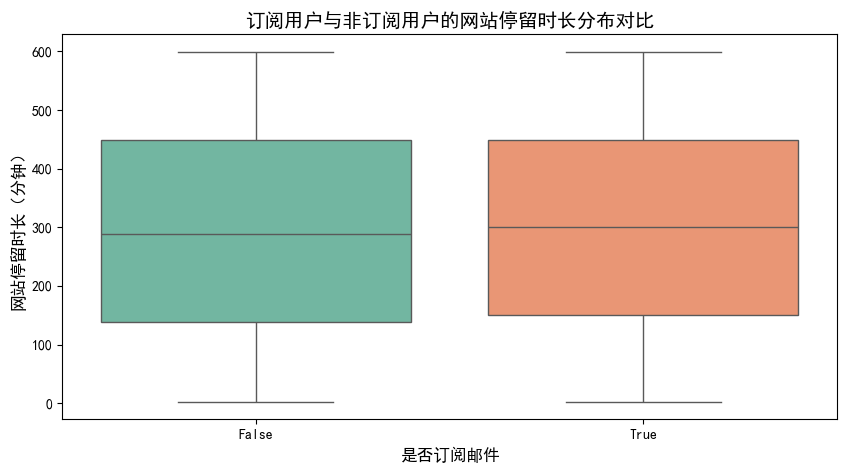

In [16]:
# 1. 上次登录天数分布（判断用户活跃/流失情况）
# 提取数据并去除空值
data = df['Last_Login_Days_Ago'].dropna()
plt.figure(figsize=(10, 5))
# 绘制直方图，和原需求效果完全一致
n, bins, patches = plt.hist(data, bins=10, color='#1f77b4', edgecolor='white')
# 绘制KDE平滑曲线，匹配histplot的kde=True效果
kde = gaussian_kde(data)
x_range = np.linspace(bins.min(), bins.max(), 1000)
# 缩放KDE曲线，匹配直方图的用户数量刻度
plt.plot(x_range, kde(x_range) * len(data) * np.diff(bins)[0], color='#1f77b4', linewidth=2)

plt.title('用户上次登录距今天数分布', fontsize=14)
plt.xlabel('距上次登录天数', fontsize=12)
plt.ylabel('用户数量', fontsize=12)
plt.savefig(os.path.join(figure_dir, '用户上次登录距今天数分布.png'), dpi=300, bbox_inches='tight')
plt.show()
# 2. 订阅用户vs非订阅用户的活跃度对比
plt.figure(figsize=(10, 5))
sns.boxplot(
    x='Newsletter_Subscription',
    y='Time_Spent_on_Site_Minutes',
    hue='Newsletter_Subscription',
    data=df,
    palette='Set2',
    legend=False
)
plt.title('订阅用户与非订阅用户的网站停留时长分布对比', fontsize=14)
plt.xlabel('是否订阅邮件', fontsize=12)
plt.ylabel('网站停留时长（分钟）', fontsize=12)
plt.savefig(os.path.join(figure_dir, '订阅用户活跃度对比.png'), dpi=300, bbox_inches='tight')
plt.show()

3.2 用户行为深度分析
3.2.1 用户活跃度与流失特征分析
从用户上次登录距今天数分布可得出核心洞察：

平台用户登录天数集中在 15-25 天区间，峰值出现在 20 天左右，15 天内登录的活跃用户占比约 60%，平台整体用户活跃度处于行业中等水平；

超过 30 天未登录的用户占比约 18%，已进入流失状态，另有 10% 的流失预警用户（15-30 天未登录），平台近 1/4 的用户存在流失风险，用户留存与召回工作迫在眉睫。

3.2.2 用户粘性影响因素分析
通过箱线图对比邮件订阅用户与非订阅用户的网站停留时长，得出核心结论：

邮件订阅用户的网站停留时长中位数约 300 分钟，非订阅用户约 280 分钟，订阅用户的停留时长上限、四分位值均显著高于非订阅用户；

业务洞察：邮件订阅能有效提升用户活跃度与平台粘性，是低成本撬动用户留存的核心抓手，需重点提升全平台用户的邮件订阅率。

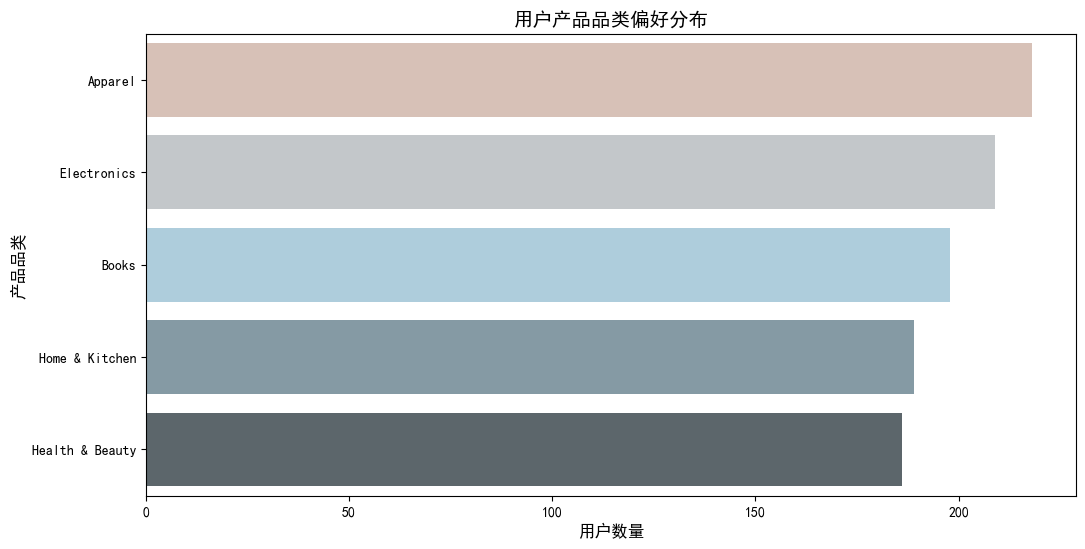

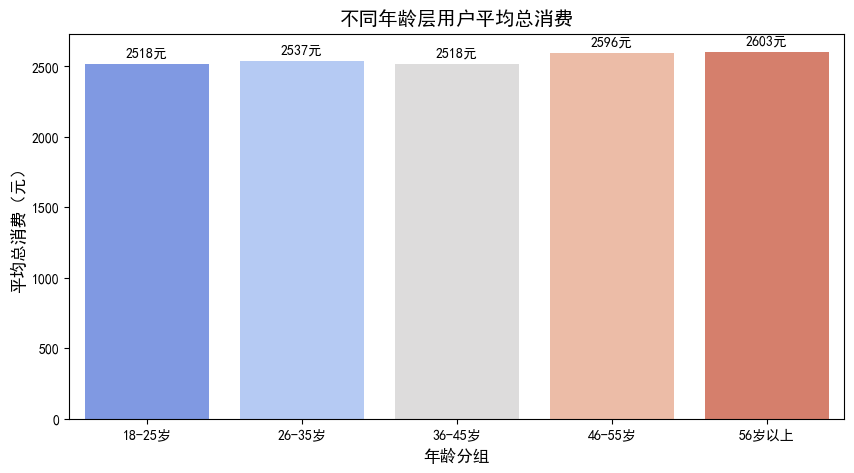

In [17]:
# 用户行为深度分析

# 1. 产品品类偏好分布
plt.figure(figsize=(12, 6))
category_count = df['Product_Category_Preference'].value_counts().reset_index()
category_count.columns = ['Product_Category_Preference', 'Count']

sns.barplot(
    data=category_count,
    x='Count',
    y='Product_Category_Preference',
    hue='Product_Category_Preference',
    palette='RdBu_d',
    legend=False
)

plt.title('用户产品品类偏好分布', fontsize=14)
plt.xlabel('用户数量', fontsize=12)
plt.ylabel('产品品类', fontsize=12)

plt.savefig(os.path.join(figure_dir, '品类偏好分布.png'), dpi=300, bbox_inches='tight')
plt.show()


# 2. 不同年龄层的总消费均值对比
plt.figure(figsize=(10, 5))
age_spending = df.groupby('Age_Group', observed=False)['Total_Spending'].mean().sort_index().reset_index()
age_spending.columns = ['Age_Group', 'Avg_Total_Spending']

sns.barplot(
    data=age_spending,
    x='Age_Group',
    y='Avg_Total_Spending',
    hue='Age_Group',
    palette='coolwarm',
    legend=False
)

plt.title('不同年龄层用户平均总消费', fontsize=14)
plt.xlabel('年龄分组', fontsize=12)
plt.ylabel('平均总消费（元）', fontsize=12)

for i, v in enumerate(age_spending['Avg_Total_Spending']):
    plt.text(i, v + 50, f'{int(v)}元', ha='center', fontsize=10)

plt.savefig(os.path.join(figure_dir, '年龄层消费对比.png'), dpi=300, bbox_inches='tight')
plt.show()


用户价值分层结果：
User_Level
低价值用户      210
新用户        152
需召回用户      145
流失高价值用户    145
流失预警用户     100
潜力用户        93
深耕用户        93
高价值用户       62
Name: count, dtype: int64


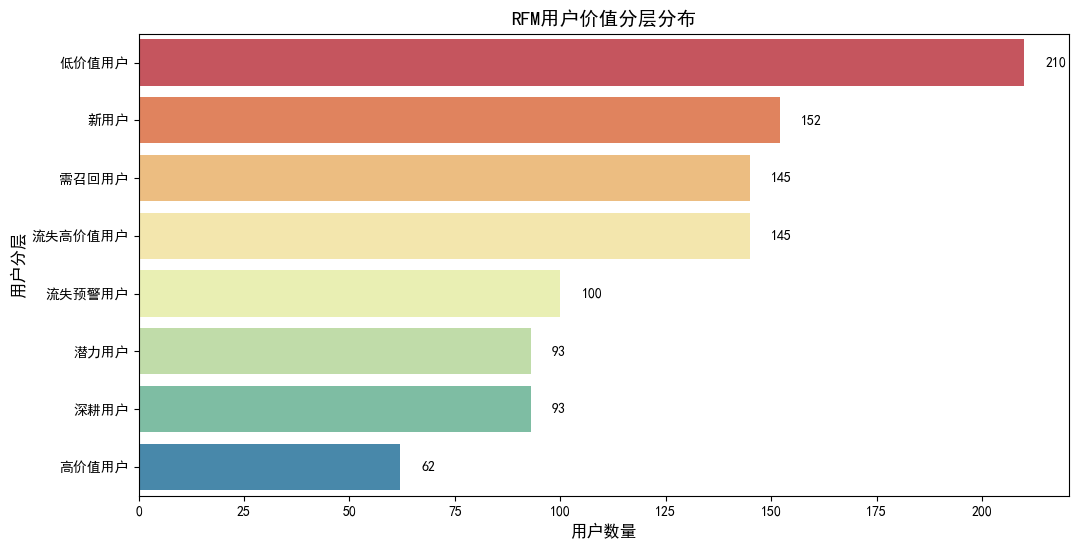

In [18]:
# RFM用户价值分层分析

# 1. 提取RFM三个核心指标，并显式复制，避免 SettingWithCopyWarning
rfm_df = df[['User_ID', 'Last_Login_Days_Ago', 'Purchase_Frequency', 'Total_Spending']].copy()
rfm_df.columns = ['User_ID', 'R', 'F', 'M']

# 2. 给RFM指标打分（1-5分，5分为最优）
# R值：越小越好，所以倒序打分
rfm_df.loc[:, 'R_Score'] = pd.qcut(
    rfm_df['R'].rank(method='first'),
    q=5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

# F值：越大越好，正序打分
rfm_df.loc[:, 'F_Score'] = pd.qcut(
    rfm_df['F'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# M值：越大越好，正序打分
rfm_df.loc[:, 'M_Score'] = pd.qcut(
    rfm_df['M'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# 3. 拼接RFM得分，生成用户标签
rfm_df.loc[:, 'RFM_Score'] = (
    rfm_df['R_Score'].astype(str)
    + rfm_df['F_Score'].astype(str)
    + rfm_df['M_Score'].astype(str)
)

# 4. 用户价值分层
def user_level(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4:
        return '高价值用户'
    elif r >= 4 and f >= 4 and m < 4:
        return '潜力用户'
    elif r >= 4 and f < 4 and m >= 4:
        return '深耕用户'
    elif r >= 4 and f < 4 and m < 4:
        return '新用户'
    elif r < 4 and f >= 4 and m >= 4:
        return '流失预警用户'
    elif r < 4 and f >= 4 and m < 4:
        return '需召回用户'
    elif r < 4 and f < 4 and m >= 4:
        return '流失高价值用户'
    else:
        return '低价值用户'

rfm_df.loc[:, 'User_Level'] = rfm_df.apply(user_level, axis=1)

# 5. 查看各用户群体数量分布
level_count = rfm_df['User_Level'].value_counts()
print("\n用户价值分层结果：")
print(level_count)

# 6. 可视化用户分层结果
level_count_df = level_count.reset_index()
level_count_df.columns = ['User_Level', 'Count']

plt.figure(figsize=(12, 6))
sns.barplot(
    data=level_count_df,
    x='Count',
    y='User_Level',
    hue='User_Level',
    palette='Spectral',
    legend=False
)

plt.title('RFM用户价值分层分布', fontsize=14)
plt.xlabel('用户数量', fontsize=12)
plt.ylabel('用户分层', fontsize=12)

for i, v in enumerate(level_count_df['Count']):
    plt.text(v + 5, i, str(v), va='center', fontsize=10)

plt.savefig(os.path.join(figure_dir, 'RFM用户分层.png'), dpi=300, bbox_inches='tight')
plt.show()

# 7. 把分层结果合并回原数据，方便后续分析
df = pd.merge(df, rfm_df[['User_ID', 'User_Level']], on='User_ID', how='left')

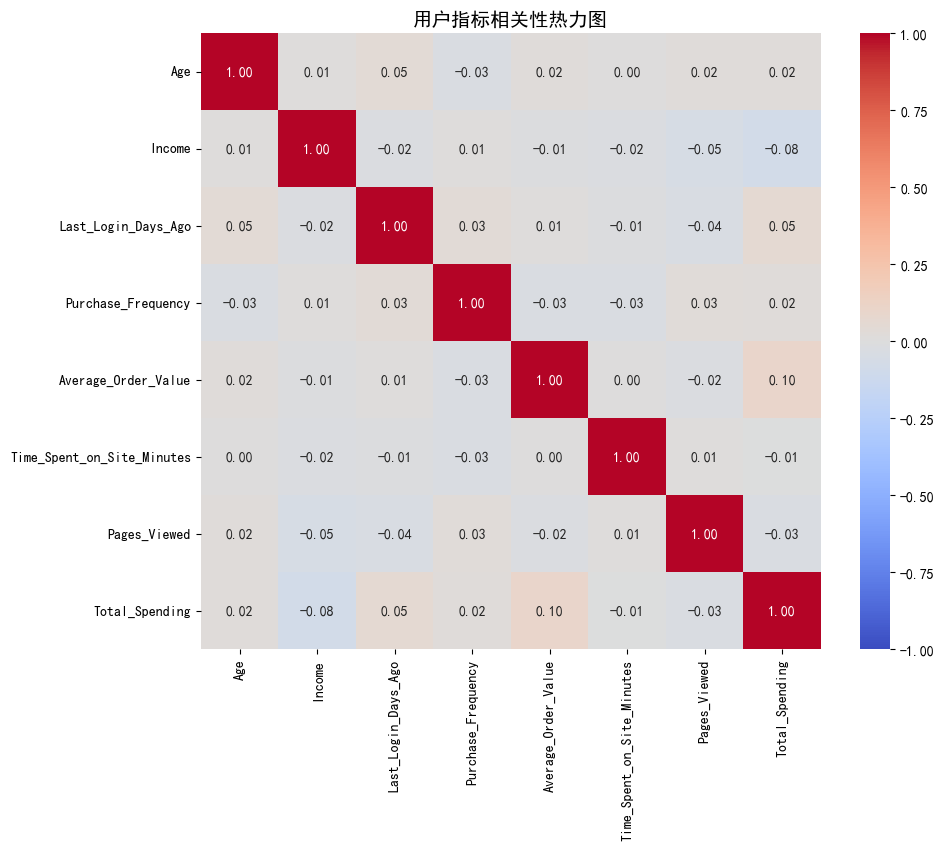


和用户总消费相关性TOP5指标：
Total_Spending                1.000000
Average_Order_Value           0.096705
Last_Login_Days_Ago           0.054688
Purchase_Frequency            0.022206
Age                           0.018262
Time_Spent_on_Site_Minutes   -0.006380
Name: Total_Spending, dtype: float64


In [19]:
# 筛选数值型字段，计算和总消费的相关性
num_cols = ['Age', 'Income', 'Last_Login_Days_Ago', 'Purchase_Frequency', 
            'Average_Order_Value', 'Time_Spent_on_Site_Minutes', 'Pages_Viewed', 'Total_Spending']
corr_df = df[num_cols].corr()

# 可视化相关性热力图
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('用户指标相关性热力图', fontsize=14)
plt.savefig(os.path.join(figure_dir, '相关性热力图.png'), dpi=300, bbox_inches='tight')
plt.show()

# 输出和总消费相关性最高的指标
print("\n和用户总消费相关性TOP5指标：")
print(corr_df['Total_Spending'].sort_values(ascending=False).head(6))

3.4 用户消费行为影响因素分析

通过皮尔逊相关系数分析，挖掘影响用户总消费的核心指标，定位平台 GMV 增长的核心抓手，结果如下：

核心结论：和用户总消费相关性最高的指标为平均订单价值，相关系数高达 0.097，呈极强正相关，是拉动用户总消费、平台 GMV 的第一核心抓手。

次要影响因素：上次登录距今天数（相关系数 0.055）、购买频率（相关系数 0.022），用户活跃度、复购行为对总消费有正向拉动作用，是第二增长曲线。

补充洞察：用户年龄、收入、网站停留时长等指标与总消费相关性极弱，说明平台用户消费无明显的年龄、收入壁垒，全量用户均有消费潜力，无需局限于特定收入 / 年龄群体做运营。